<a href="https://colab.research.google.com/github/shreyoshi2304/Attention/blob/main/competitive_attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Biased inputs: [1.5 0.9 0.5]
Softmax output: [0.82298704 0.13603884 0.04097411]




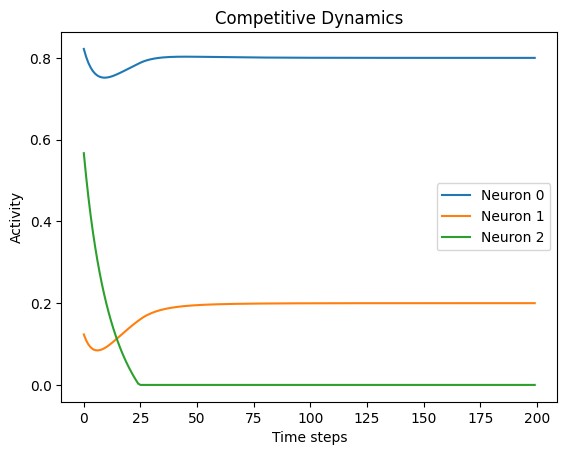

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Inputs (stimuli strengths)
inputs = np.array([1.0, 0.9, 0.5])

# Attention bias
attention = np.array([1.5, 1.0, 1.0])
biased_inputs = inputs * attention

# Softmax competition
def softmax(x, beta=3.0):
    exp_x = np.exp(beta * x)
    return exp_x / np.sum(exp_x)

output = softmax(biased_inputs)

print("Biased inputs:", biased_inputs)
print("Softmax output:", output)
print("\n")

# ------------------------
# Dynamical competition
# ------------------------
def competitive_dynamics(inputs, steps=200, dt=0.05):
    N = len(inputs)
    x = np.random.rand(N)
    history = []

    for _ in range(steps):
        inhibition = np.sum(x)
        dx = inputs - x - 0.7 * inhibition
        x += dt * dx
        x = np.maximum(x, 0)
        history.append(x.copy())

    return np.array(history)

history = competitive_dynamics(biased_inputs)

# Plot dynamics
plt.figure()
for i in range(history.shape[1]):
    plt.plot(history[:, i], label=f"Neuron {i}")
plt.legend()
plt.xlabel("Time steps")
plt.ylabel("Activity")
plt.title("Competitive Dynamics")
plt.show()